<a href="https://colab.research.google.com/github/saniyaverma/DGFL-for-plant-disease-detection/blob/main/CL_Tomato_IID_v_s_OOD_EfficientNet_B0(15).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Centralized Baseline | Tomato

**Dataset Download**

In [34]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [35]:
# !kaggle datasets download -d saniyaverma914/cropdg-unified-multidomain

In [36]:
# !unzip cropdg-unified-multidomain.zip

**Imports and Setup**

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [38]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import copy

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**Paths**

In [39]:
BASE_DIR = "/content"

PV_TOMATO   = os.path.join(BASE_DIR, "PV", "Tomato")
CCMT_TOMATO = os.path.join(BASE_DIR, "CCMT", "Tomato")
PD_TOMATO   = os.path.join(BASE_DIR, "PD", "Tomato")

In [40]:
checkpoint_path = "/content/drive/MyDrive/efficientnetb0_checkpoint.pth"

**Collect Samples**

In [41]:
def collect_samples(root_dir, class_to_idx=None):
    samples = []

    if class_to_idx is None:
        classes = sorted(os.listdir(root_dir))
        class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
    else:
        classes = list(class_to_idx.keys())

    for cls in classes:
        class_path = os.path.join(root_dir, cls)
        if not os.path.isdir(class_path):
            continue

        for img in os.listdir(class_path):
            samples.append({
                "path": os.path.join(class_path, img),
                "label": class_to_idx[cls],
                "class_name": cls
            })
    return samples, class_to_idx

In [42]:
# Build mapping from PV first
pv_samples, class_to_idx = collect_samples(PV_TOMATO)
ccmt_samples, _ = collect_samples(CCMT_TOMATO, class_to_idx)
pd_samples, _   = collect_samples(PD_TOMATO, class_to_idx)

class_names = list(class_to_idx.keys())

train_samples = pv_samples + ccmt_samples

print("Total Training Pool:", len(train_samples))
print("PD Test Samples:", len(pd_samples))
print("Classes:", class_names)

Total Training Pool: 37432
PD Test Samples: 640
Classes: ['Blight', 'Healthy', 'Leaf_spot', 'Viral']


**Train/Test/Val split: 70/15/15**

In [43]:
labels = [s["label"] for s in train_samples]

train_idx, temp_idx = train_test_split(
    range(len(train_samples)),
    test_size=0.30,
    stratify=labels,
    random_state=42
)

temp_labels = [labels[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_labels,
    random_state=42
)

train_data = [train_samples[i] for i in train_idx]
val_data   = [train_samples[i] for i in val_idx]
iid_test_data = [train_samples[i] for i in test_idx]
ood_test_data = pd_samples

print("Train:", len(train_data))
print("Val:", len(val_data))
print("IID Test:", len(iid_test_data))
print("OOD Test (PD):", len(ood_test_data))

Train: 26202
Val: 5615
IID Test: 5615
OOD Test (PD): 640


**Dataset Class**

In [44]:
class CropDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample["path"]).convert("RGB")
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

**Transforms**

In [45]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(0.4,0.4,0.4,0.05),
    transforms.GaussianBlur(kernel_size=3),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

**Data Loaders**

In [46]:
batch_size = 32

train_loader = DataLoader(
    CropDataset(train_data, train_transform),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    CropDataset(val_data, test_transform),
    batch_size=batch_size,
    shuffle=False
)

iid_test_loader = DataLoader(
    CropDataset(iid_test_data, test_transform),
    batch_size=batch_size,
    shuffle=False
)

ood_test_loader = DataLoader(
    CropDataset(ood_test_data, test_transform),
    batch_size=batch_size,
    shuffle=False
)

**Class Weights**

In [47]:
label_list = [s["label"] for s in train_data]
counts = Counter(label_list)

total = len(train_data)
num_classes = len(class_names)

weights = [total / (num_classes * counts[i]) for i in range(num_classes)]
weights = torch.tensor(weights).float().to(device)

print("Class counts (Train):", counts)

Class counts (Train): Counter({2: 10928, 0: 6592, 3: 5818, 1: 2864})


**Model**

In [48]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=0.1
)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

**Training**

In [49]:
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

num_epochs = 15
best_val_acc = 0
patience = 5
counter = 0
start_epoch = 0

best_model = copy.deepcopy(model.state_dict())

# If checkpoint exists → load it
if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    best_model = checkpoint["best_model_state"]

    print(f"Resuming from epoch {start_epoch}")

for epoch in range(start_epoch, num_epochs):
    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    scheduler.step()

    avg_loss = running_loss / len(train_loader)
    val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f} | Val Acc={val_acc:.4f}")

    # Update best model first
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = copy.deepcopy(model.state_dict())

    # Save checkpoint AFTER updating best_val_acc
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_acc": best_val_acc,
        "best_model_state": best_model
    }, checkpoint_path)

print("Training complete.")

100%|██████████| 819/819 [08:27<00:00,  1.61it/s]


Epoch 1: Loss=0.8117 | Val Acc=0.8595


100%|██████████| 819/819 [08:03<00:00,  1.69it/s]


Epoch 2: Loss=0.6899 | Val Acc=0.8867


100%|██████████| 819/819 [08:12<00:00,  1.66it/s]


...

Epoch 13: Loss=0.4977 | Val Acc=0.9713


100%|██████████| 819/819 [07:40<00:00,  1.78it/s]


Epoch 14: Loss=0.4933 | Val Acc=0.9747


100%|██████████| 819/819 [07:37<00:00,  1.79it/s]


Epoch 15: Loss=0.4890 | Val Acc=0.9736
Training complete.


**Evaluation**


Classification Report (IID (PV+CCMT Test Split)):

              precision    recall  f1-score   support

      Blight       0.97      0.95      0.96      1413
     Healthy       0.97      0.99      0.98       614
   Leaf_spot       0.97      0.97      0.97      2341
       Viral       0.98      0.98      0.98      1247

    accuracy                           0.97      5615
   macro avg       0.97      0.97      0.97      5615
weighted avg       0.97      0.97      0.97      5615



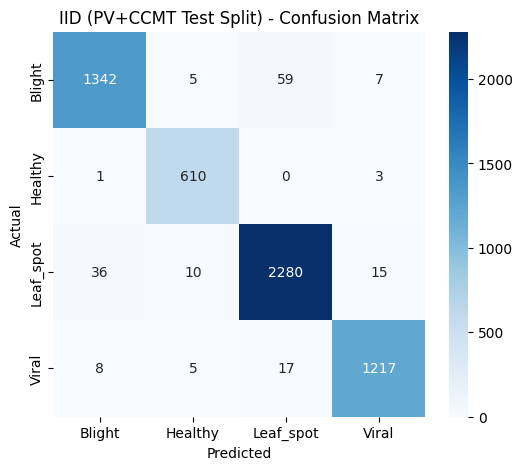


Classification Report (OOD (PD Unseen Domain)):

              precision    recall  f1-score   support

      Blight       0.55      0.56      0.55       194
     Healthy       0.44      0.60      0.50        62
   Leaf_spot       0.62      0.50      0.55       255
       Viral       0.33      0.40      0.36       129

    accuracy                           0.50       640
   macro avg       0.48      0.51      0.49       640
weighted avg       0.52      0.50      0.51       640



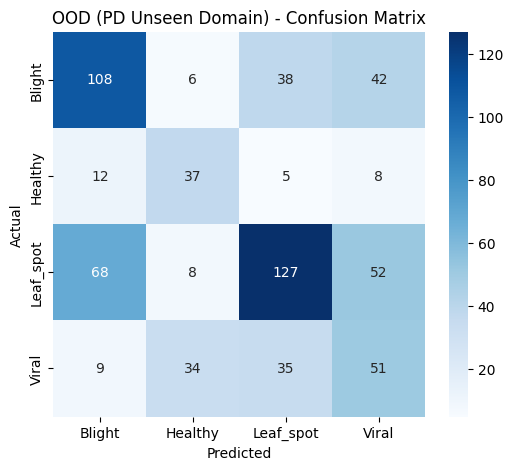

In [50]:
model.load_state_dict(best_model)

def full_evaluation(model, loader, name="Test"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"\nClassification Report ({name}):\n")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names,
                cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# IID
full_evaluation(model, iid_test_loader, name="IID (PV+CCMT Test Split)")

# OOD
full_evaluation(model, ood_test_loader, name="OOD (PD Unseen Domain)")